In [16]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt


In [17]:
# ==========================================
# 1. CARGA DE DATOS
# ==========================================
print("Cargando datasets completos...")

try:
    # Pandas descomprime al vuelo si detecta la extensión zip
    products = pd.read_csv('../data/products.csv.zip')
    orders = pd.read_csv('../data/orders.csv.zip')
    order_details = pd.read_csv('../data/order_products__prior.csv.zip')
    print("¡Datos cargados correctamente!")
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Verifica que los archivos .csv.zip estén en la carpeta 'data'.")

Cargando datasets completos...
¡Datos cargados correctamente!


In [18]:
# ==========================================
# 2. PREPROCESAMIENTO Y CRUCE DE TABLAS
# ==========================================
print("Fusionando tablas (esto puede tardar un poco con todos los datos)...")

# Unimos detalle de productos con órdenes para obtener (Usuario, Producto)
merged_data = pd.merge(order_details, orders[['order_id', 'user_id']], on='order_id')

# --- SIN LÍMITES ---
# Procesamos el dataset entero. 
total_usuarios = merged_data['user_id'].nunique()
total_transacciones = len(merged_data)

print(f"¡Filtros eliminados! Analizando {total_transacciones:,} transacciones de {total_usuarios:,} usuarios.")

Fusionando tablas (esto puede tardar un poco con todos los datos)...
¡Filtros eliminados! Analizando 32,434,489 transacciones de 206,209 usuarios.


In [19]:

# ==========================================
# 3. CREACIÓN DE LA MATRIZ DE UTILIDAD (Sparse)
# ==========================================
print("Creando matriz dispersa Usuarios x Productos (Masiva)...")

# Contamos transacciones
user_product_counts = merged_data.groupby(['user_id', 'product_id']).size().reset_index(name='count')

# Mapeo de IDs reales a índices de matriz (0, 1, 2...)
user_product_counts['user_id'] = user_product_counts['user_id'].astype('category')
user_product_counts['product_id'] = user_product_counts['product_id'].astype('category')

user_ids = user_product_counts['user_id'].cat.codes
product_ids = user_product_counts['product_id'].cat.codes

# Creamos la matriz dispersa
# Aunque sean millones de datos, csr_matrix es muy eficiente en memoria
sparse_matrix = csr_matrix((user_product_counts['count'], (user_ids, product_ids)))

print(f"Matriz Masiva creada: {sparse_matrix.shape} (Usuarios x Productos)")
print(f"Grado de dispersión (Sparsity): {100 * (1 - sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1])):.4f}%")

Creando matriz dispersa Usuarios x Productos (Masiva)...
Matriz Masiva creada: (206209, 49677) (Usuarios x Productos)
Grado de dispersión (Sparsity): 99.8701%


In [20]:

# ==========================================
# 4. APLICACIÓN DE SVD TRUNCADO (Técnica Unidad 1)
# ==========================================
# Con el dataset completo, k=10 componentes podrían capturar perfiles más generales.
# SVD Truncado es ideal aquí porque no necesita calcular la matriz densa gigante.
k_components = 10

print(f"Aplicando SVD con k={k_components} a todo el dataset...")
svd = TruncatedSVD(n_components=k_components, random_state=42)
user_profiles_reduced = svd.fit_transform(sparse_matrix)

print("¡Reducción de dimensionalidad completada!")

Aplicando SVD con k=10 a todo el dataset...
¡Reducción de dimensionalidad completada!


In [21]:
# ==========================================
# 5. INTERPRETACIÓN DE RESULTADOS
# ==========================================
# Diccionario para traducir códigos de matriz a nombres reales
product_cat = user_product_counts['product_id'].cat.categories
product_code_to_id = dict(enumerate(product_cat))

def mostrar_perfil(component_idx, n_top=5):
    comp_row = svd.components_[component_idx]
    # Ordenamos por peso absoluto (tanto positivo como negativo importa en SVD)
    sorted_indices = np.argsort(np.abs(comp_row))[::-1][:n_top]
    
    print(f"\n--- Perfil Latente {component_idx + 1} (Principales Productos) ---")
    for idx in sorted_indices:
        real_prod_id = product_code_to_id[idx]
        prod_name = products[products['product_id'] == real_prod_id]['product_name'].values
        if len(prod_name) > 0:
            weight = comp_row[idx]
            # El signo (+/-) indica correlación con el concepto
            print(f"  - {prod_name[0]} (Peso: {weight:.4f})")

# Mostramos los primeros perfiles descubiertos en la data completa
mostrar_perfil(0) 
mostrar_perfil(1)
mostrar_perfil(2)



--- Perfil Latente 1 (Principales Productos) ---
  - Banana (Peso: 0.4284)
  - Bag of Organic Bananas (Peso: 0.3670)
  - Organic Strawberries (Peso: 0.2901)
  - Organic Baby Spinach (Peso: 0.2374)
  - Organic Hass Avocado (Peso: 0.2372)

--- Perfil Latente 2 (Principales Productos) ---
  - Banana (Peso: 0.7305)
  - Bag of Organic Bananas (Peso: -0.5555)
  - Organic Hass Avocado (Peso: -0.1971)
  - Organic Strawberries (Peso: -0.1000)
  - Organic Raspberries (Peso: -0.0992)

--- Perfil Latente 3 (Principales Productos) ---
  - Bag of Organic Bananas (Peso: 0.5324)
  - Organic Baby Spinach (Peso: -0.3460)
  - Banana (Peso: 0.3237)
  - Organic Avocado (Peso: -0.2302)
  - Limes (Peso: -0.1897)


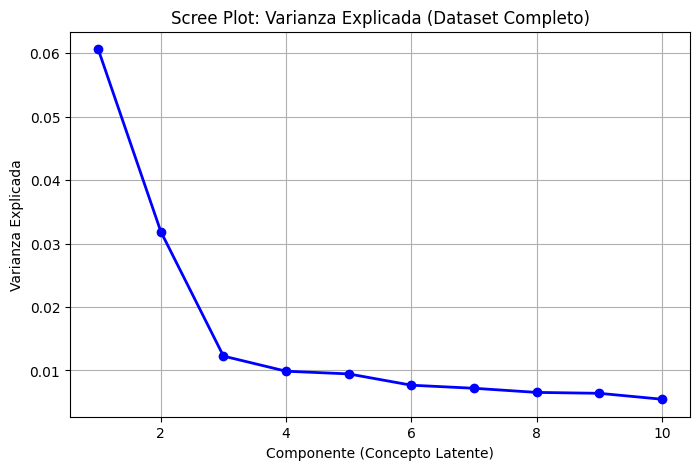

In [22]:

# ==========================================
# 6. SCREE PLOT
# ==========================================
explained_variance = svd.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(range(1, k_components + 1), explained_variance, 'bo-', linewidth=2)
plt.title('Scree Plot: Varianza Explicada (Dataset Completo)')
plt.xlabel('Componente (Concepto Latente)')
plt.ylabel('Varianza Explicada')
plt.grid(True)
plt.show()